#### Data simulation
4.1 Data
- n = 100
- y_i = 0.25 sin(π x_i) + ϵ_i
- x_i ∼ U(0, 1)
- ϵ_i ∼ (1 − η)N(0, σ²) + ηN(0, 25σ²)
- σ = 0.5
- η = 0.1
- p(x) = 0.3 + 0.5 sin²(5(x + 0.2))


In [2]:
import sys
sys.path.append("../src")
from data_simulation import data_simulation,simulate_once
from missing_mechanism import missing_mechanism
from slms import slms_estimator
from kernels import gaussian_kernel,epanechnikov_kernel
from psi_functions import huber_psi
from scipy.stats import median_abs_deviation
from evaluation import select_bandwidth,compute_mise,plot_comparison
import matplotlib.pyplot as plt
import numpy as np
from ilms import ilms_estimator 
from nadaraya_watson import nadaraya_watson

القيمة المثلى لـ h: 0.150


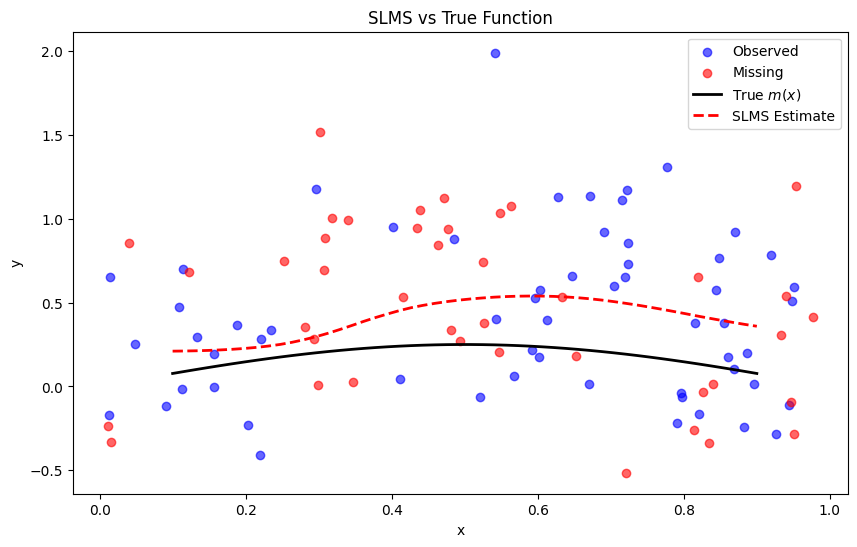

In [3]:
 
from scipy.stats import median_abs_deviation
x_grid = np.linspace(0.1, 0.9, 50)
h_grid = np.arange(0.1,1.0,0.05)
x0 = 0.5
x,y=data_simulation()
delta = missing_mechanism(x=x)
optimal_h,rcv_vals = select_bandwidth(
    x=x,
    y=y,
    delta=delta,
    h_grid=h_grid,
    psi=huber_psi,
    kernel=gaussian_kernel,
    scale_estimator=lambda y: median_abs_deviation(y,nan_policy='omit')
)
print(f"القيمة المثلى لـ h: {optimal_h:.3f}")    

m_estimates = []

for x0 in x_grid:
    m_hat = slms_estimator(x, y, delta, x0, h=optimal_h, psi=huber_psi, kernel=gaussian_kernel)
    m_estimates.append(m_hat)

# الرسم
plt.figure(figsize=(10, 6))
plt.scatter(x[delta==1], y[delta==1], label='Observed', alpha=0.6, color='blue')
plt.scatter(x[delta==0], y[delta==0], label='Missing', alpha=0.6, color='red')
plt.plot(x_grid, 0.25 * np.sin(np.pi * x_grid), 'k-', label='True $m(x)$', lw=2)
plt.plot(x_grid, m_estimates, 'r--', label='SLMS Estimate', lw=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('SLMS vs True Function')
plt.legend()
plt.show()

In [4]:
x0 = 0.5
h_slms = 0.3
optimal_h, _ = select_bandwidth(
    x=x,
    y=y,
    delta=delta,
    h_grid=np.arange(0.1, 1.0, 0.1),
    psi=huber_psi,
    kernel=gaussian_kernel,
    scale_estimator=median_abs_deviation
)

y_imputed = y.copy()
for i in range(len(x)):
    if delta[i] == 0:
        y_imputed[i] = slms_estimator(
            x=x,
            y=y,
            delta=delta,
            x0=x[i],
            h=optimal_h,
            psi=huber_psi,
            kernel=gaussian_kernel
        )
optimal_gamma, _ = select_bandwidth(
    x=x,
    y=y_imputed,
    delta=np.ones(len(x)),  
    h_grid=np.arange(0.05, 0.99, 0.05),
    psi=huber_psi,
    kernel=gaussian_kernel,
    scale_estimator=median_abs_deviation
)

m_hat_ilms = ilms_estimator(
    x=x,
    y=y,
    delta=delta,
    x0=x0,
    h=h_slms,
    gamma=optimal_gamma,
    psi=huber_psi,
    kernel=gaussian_kernel,
    imputation_kernel=gaussian_kernel
)

print(f"ILMS estimate at x0={x0}: {m_hat_ilms:.3f}")
print(f"True value: {0.25 * np.sin(np.pi * x0):.3f}")

ILMS estimate at x0=0.5: 0.433
True value: 0.250


In [5]:
x_grid = np.linspace(0.1, 0.9, 50)
slms_estimates = []
ilms_estimates = []
nw_estimates = []

for x0 in x_grid:
    # SLMS
    m_slms = slms_estimator(
        x=x,
        y=y,
        delta=delta,
        x0=x0,
        h=optimal_h,
        psi=huber_psi,
        kernel=gaussian_kernel
    )
    slms_estimates.append(m_slms)
    
    # ILMS
    m_ilms = ilms_estimator(
        x=x,
        y=y,
        delta=delta,
        x0=x0,
        h=optimal_h,
        gamma=optimal_gamma,
        psi=huber_psi,
        kernel=gaussian_kernel,
        imputation_kernel=gaussian_kernel
    )
    ilms_estimates.append(m_ilms)
    
    # Nadaraya-Watson
    m_nw = nadaraya_watson(
        x=x,
        y=y,
        delta=delta,
        x0=x0,
        h=optimal_h,
        kernel=gaussian_kernel
    )
    nw_estimates.append(m_nw)

true_values = 0.25 * np.sin(np.pi * x_grid)

<>:17: SyntaxWarning: invalid escape sequence '\R'
<>:17: SyntaxWarning: invalid escape sequence '\R'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_3604\3743094727.py:17: SyntaxWarning: invalid escape sequence '\R'
  plt.savefig('E:\Robust nonparametric estimation of regression for missing data/results/plots/comparison_all.png', dpi=300, bbox_inches='tight')


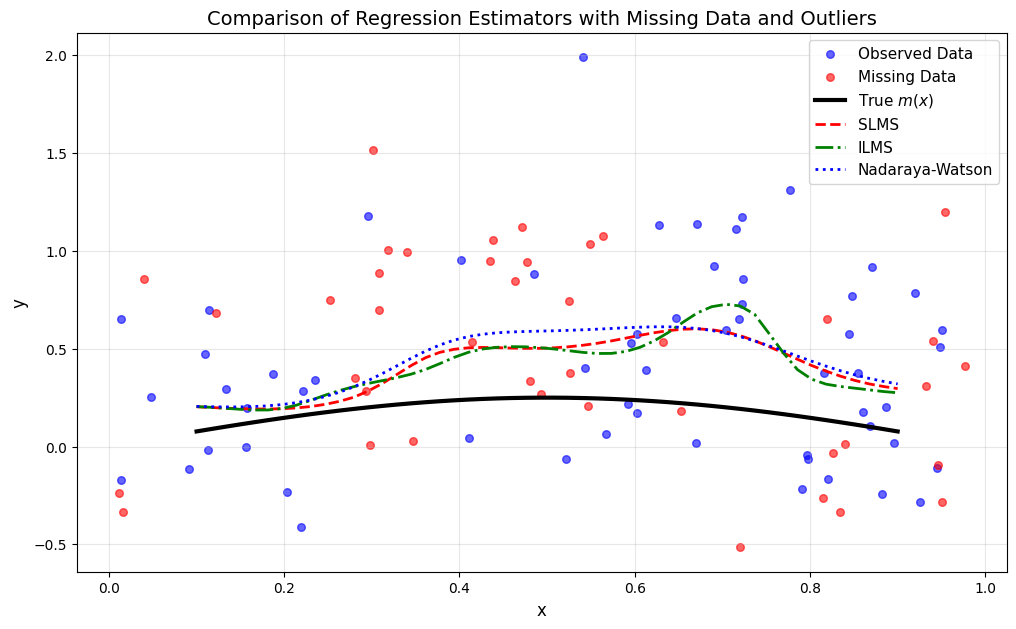

In [7]:
plt.figure(figsize=(12, 7))

plt.scatter(x[delta==1], y[delta==1], label='Observed Data', alpha=0.6, color='blue', s=30)
plt.scatter(x[delta==0], y[delta==0], label='Missing Data', alpha=0.6, color='red', s=30)

plt.plot(x_grid, true_values, 'k-', label='True $m(x)$', lw=3)
plt.plot(x_grid, slms_estimates, 'r--', label='SLMS', lw=2)
plt.plot(x_grid, ilms_estimates, 'g-.', label='ILMS', lw=2)
plt.plot(x_grid, nw_estimates, 'b:', label='Nadaraya-Watson', lw=2)

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Comparison of Regression Estimators with Missing Data and Outliers', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.savefig('E:\Robust nonparametric estimation of regression for missing data/results/plots/comparison_all.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
ise_slms = np.mean((true_values - slms_estimates)**2)
ise_ilms = np.mean((true_values - ilms_estimates)**2)
ise_nw = np.mean((true_values - nw_estimates)**2)

print(f"ISE SLMS: {ise_slms:.4f}")
print(f"ISE ILMS: {ise_ilms:.4f}")
print(f"ISE Nadaraya-Watson: {ise_nw:.4f}")


ISE SLMS: 0.0622
ISE ILMS: 0.0665
ISE Nadaraya-Watson: 0.0797


In [7]:
n_rep = 200
R = 50
x_grid = np.linspace(0.1, 0.9, R)
true_values = 0.25 * np.sin(np.pi * x_grid)

mise_slms = 0.0
mise_ilms = 0.0
mise_nw = 0.0



for rep in range(n_rep):
    x, y, delta = simulate_once()
    
   
    slms_est = [slms_estimator(x, y, delta, x0, h=optimal_h, psi=huber_psi, kernel=gaussian_kernel) for x0 in x_grid]
    ilms_est = [ilms_estimator(x, y, delta, x0, h=optimal_h, gamma=optimal_gamma, psi=huber_psi, kernel=gaussian_kernel, imputation_kernel=gaussian_kernel) for x0 in x_grid]
    nw_est = [nadaraya_watson(x, y, delta, x0, h=optimal_h, kernel=gaussian_kernel) for x0 in x_grid]
    
    
    ise_slms = np.mean((true_values - slms_est)**2)
    ise_ilms = np.mean((true_values - ilms_est)**2)
    ise_nw = np.mean((true_values - nw_est)**2)
    
    mise_slms += ise_slms
    mise_ilms += ise_ilms
    mise_nw += ise_nw


mise_slms /= n_rep
mise_ilms /= n_rep
mise_nw /= n_rep

print(f"MISE SLMS: {mise_slms:.4f}")
print(f"MISE ILMS: {mise_ilms:.4f}")
print(f"MISE Nadaraya-Watson: {mise_nw:.4f}")

MISE SLMS: 0.0171
MISE ILMS: 0.0203
MISE Nadaraya-Watson: 0.0429
